# ML Fundamentals #4: Random Forest

## Crop Recommendation using Random Forest

This project implements a Random Forest Classifier to recommend the most suitable crop based on soil nutrients and environmental conditions.

The notebook covers:

- Data Loading
- Dataset Understanding
- Exploratory Data Analysis
- Data Preprocessing
- Random Forest Training
- Out-of-Bag Evaluation
- Prediction
- Model Evaluation
- Feature Importance
- Model Serialization

In [1]:
# Import required libraries for data analysis, visualization, modeling, and saving outputs

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
# Create output directories for storing figures and tables

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

print("Output directories created successfully.")

Output directories created successfully.


## 2. Loading the Dataset

This project uses the **Crop Recommendation Dataset**, which contains soil nutrient measurements and environmental conditions to recommend the most suitable crop for cultivation.

The dataset is a multi-class classification problem where each record represents one agricultural observation.

In [5]:
# Load the Crop Recommendation dataset

df = pd.read_csv("data/raw/Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
# Save a preview of the dataset

df.head(10).to_csv(
    "outputs/tables/dataset_preview.csv",
    index=False
)

In [7]:
# Display dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2200
Columns : 8


### Insights

- The Crop Recommendation dataset has been successfully loaded.
- Each row represents one agricultural observation.
- The dataset contains soil nutrient values and environmental measurements.
- The target variable represents the recommended crop.

## 3. Understanding the Dataset

Before training the Random Forest model, we examine the dataset structure, feature information, missing values, statistical summary, and crop class distribution.

In [8]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [9]:
# Generate descriptive statistics

summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [10]:
# Save descriptive statistics

summary.to_csv(
    "outputs/tables/dataset_summary.csv"
)

In [11]:
# Check for missing values

missing = df.isnull().sum()

missing

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
# Save missing value summary

missing.to_csv(
    "outputs/tables/missing_values.csv"
)

In [13]:
# Display crop class distribution

df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [14]:
# Save crop class distribution

crop_distribution = df["label"].value_counts().reset_index()

crop_distribution.columns = ["Crop", "Count"]

crop_distribution.to_csv(
    "outputs/tables/crop_distribution.csv",
    index=False
)

### Insights

- The dataset contains numerical soil and environmental features.
- The target variable is the recommended crop label.
- No missing values are present.
- The dataset contains multiple crop classes, making this a multi-class classification problem.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the distribution of soil nutrients, environmental conditions, and crop labels before training the Random Forest model.

This section includes class distribution, feature distributions, and correlation analysis.

In [15]:
# Display the first five records

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


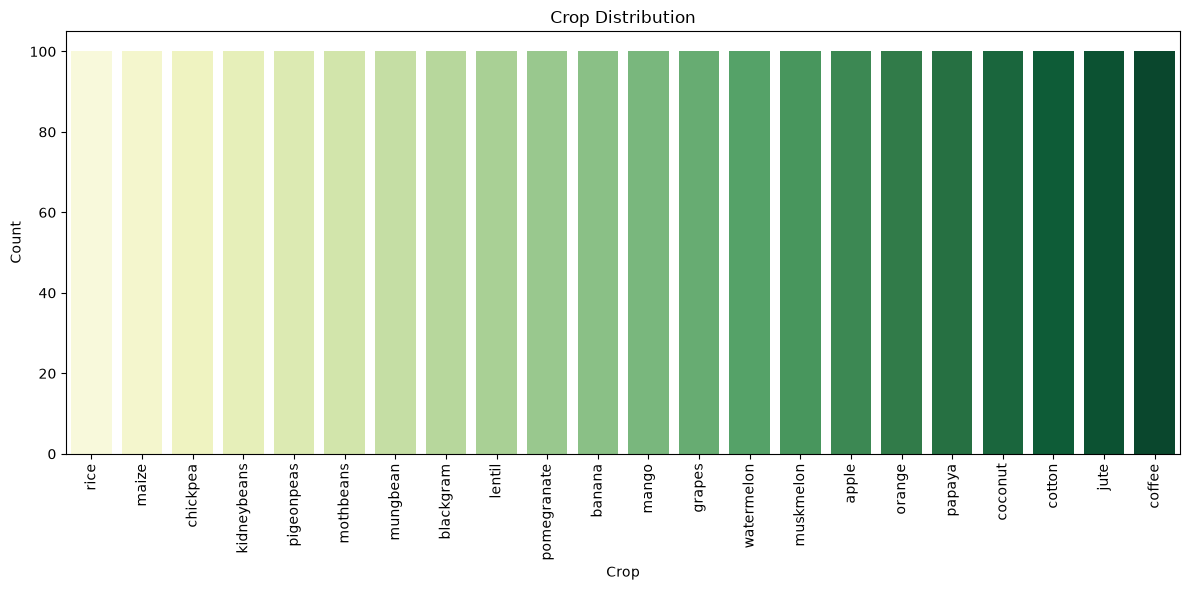

In [16]:
# Plot the crop distribution

plt.figure(figsize=(12,6))

sns.countplot(
    x="label",
    data=df,
    palette="YlGn"
)

plt.xticks(rotation=90)

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "outputs/figures/crop_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The dataset contains multiple crop categories.
- Each crop has an equal number of observations.
- The balanced distribution makes the dataset suitable for multi-class classification.

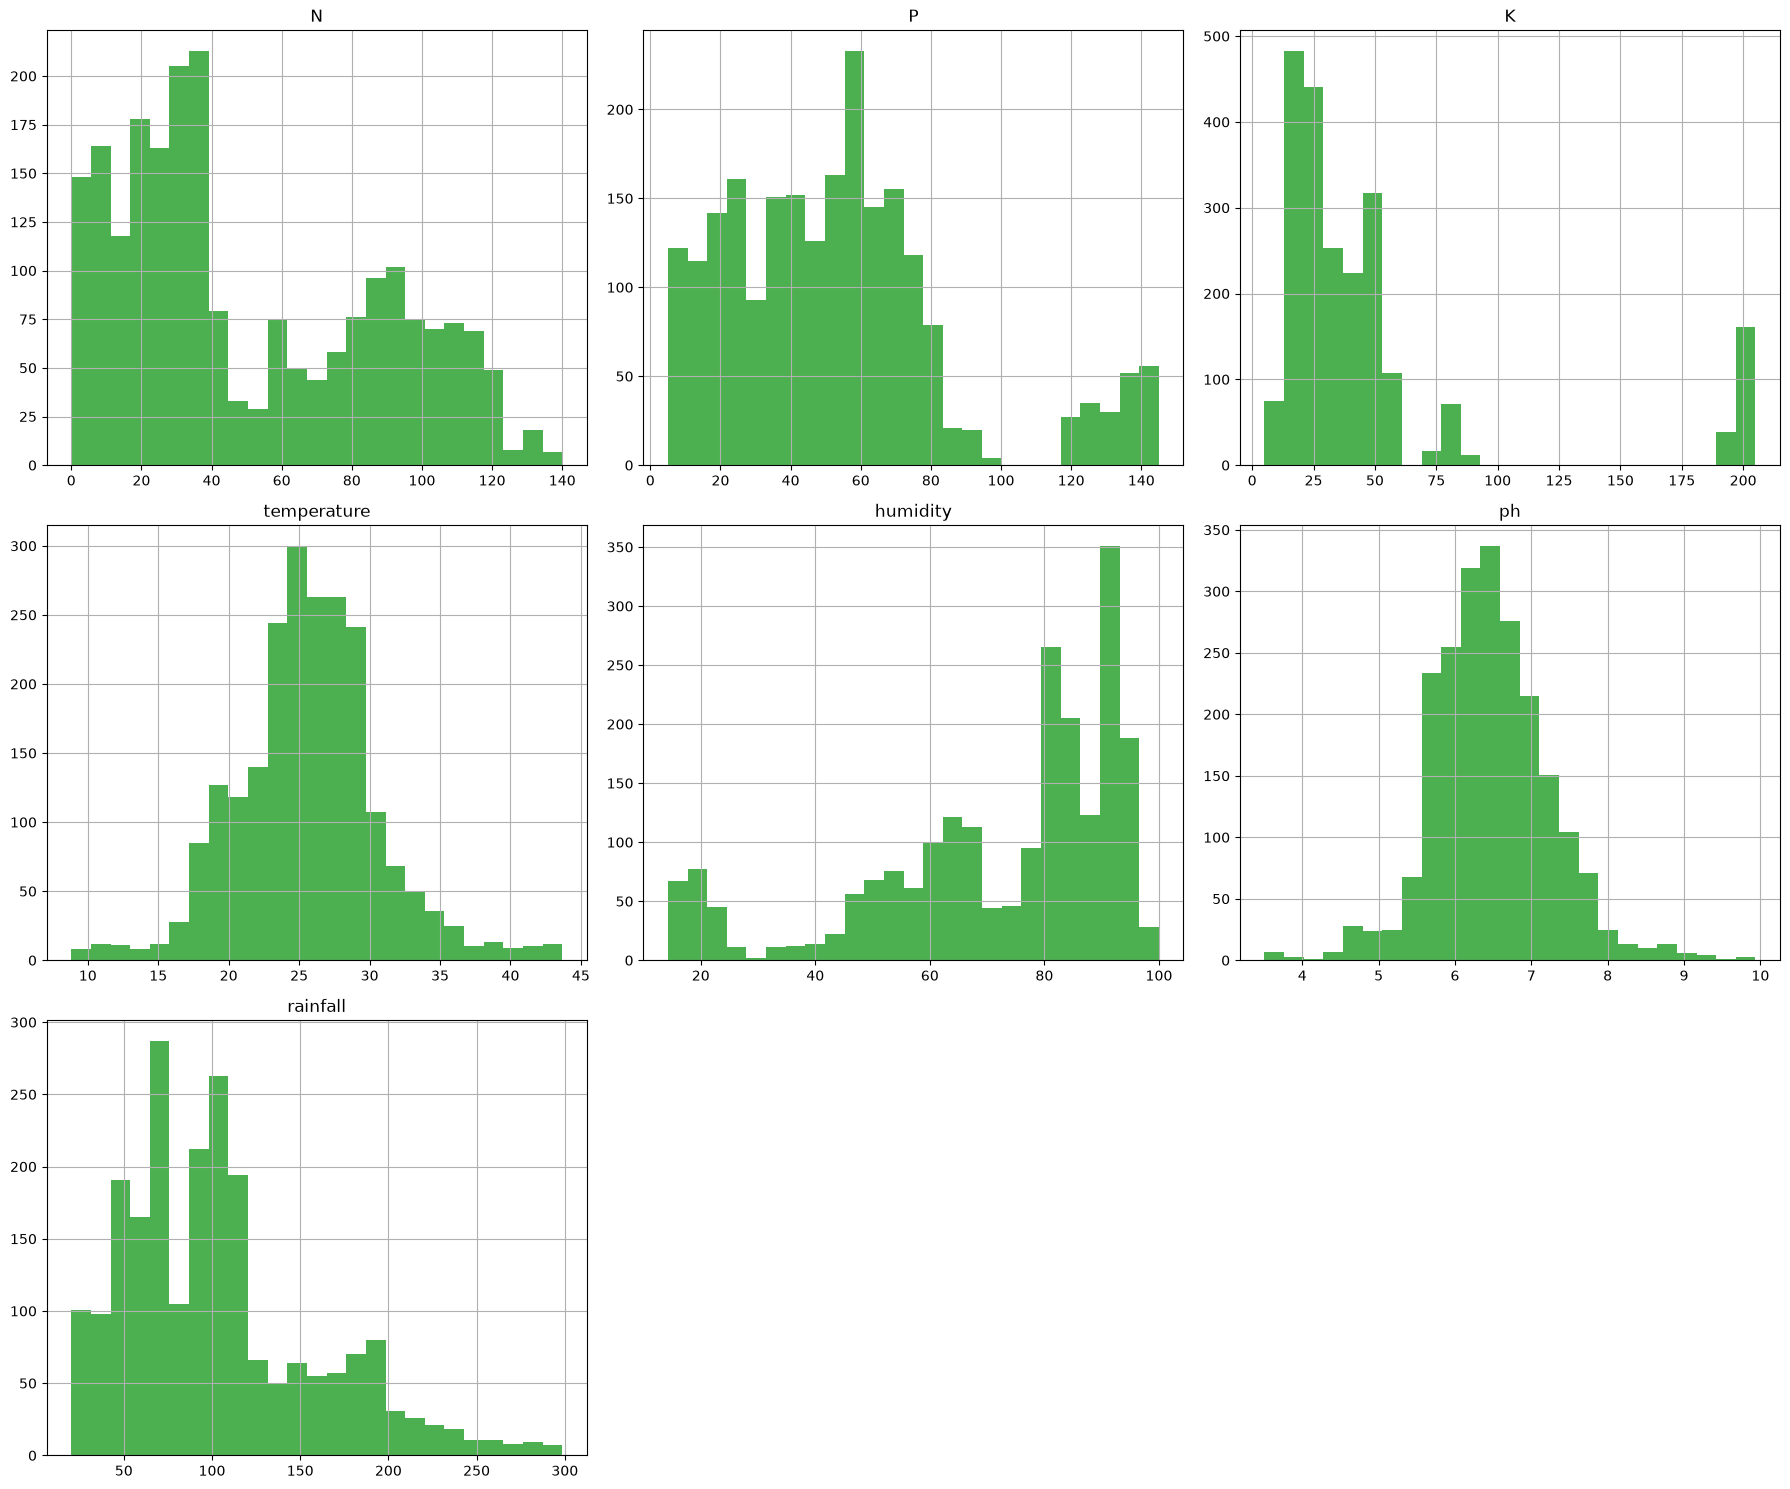

In [17]:
# Plot feature distributions

df.hist(
    figsize=(18,15),
    bins=25,
    color="#4CAF50"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Soil nutrients and environmental variables exhibit different distributions.
- Several variables contain wide value ranges, which Random Forest naturally handles without feature scaling.

In [18]:
# Compute the correlation matrix

correlation = df.drop("label", axis=1).corr()

correlation

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


In [19]:
# Save the correlation matrix

correlation.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

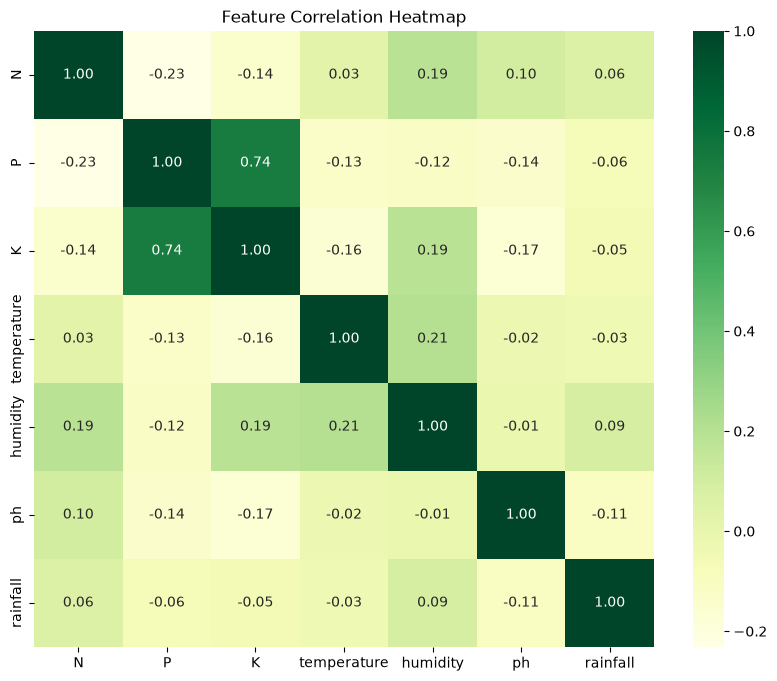

In [20]:
# Plot the correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGn",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.savefig(
    "outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Some soil nutrients and environmental variables show moderate correlations.
- Random Forest is robust to correlated predictors because each tree considers random subsets of features.

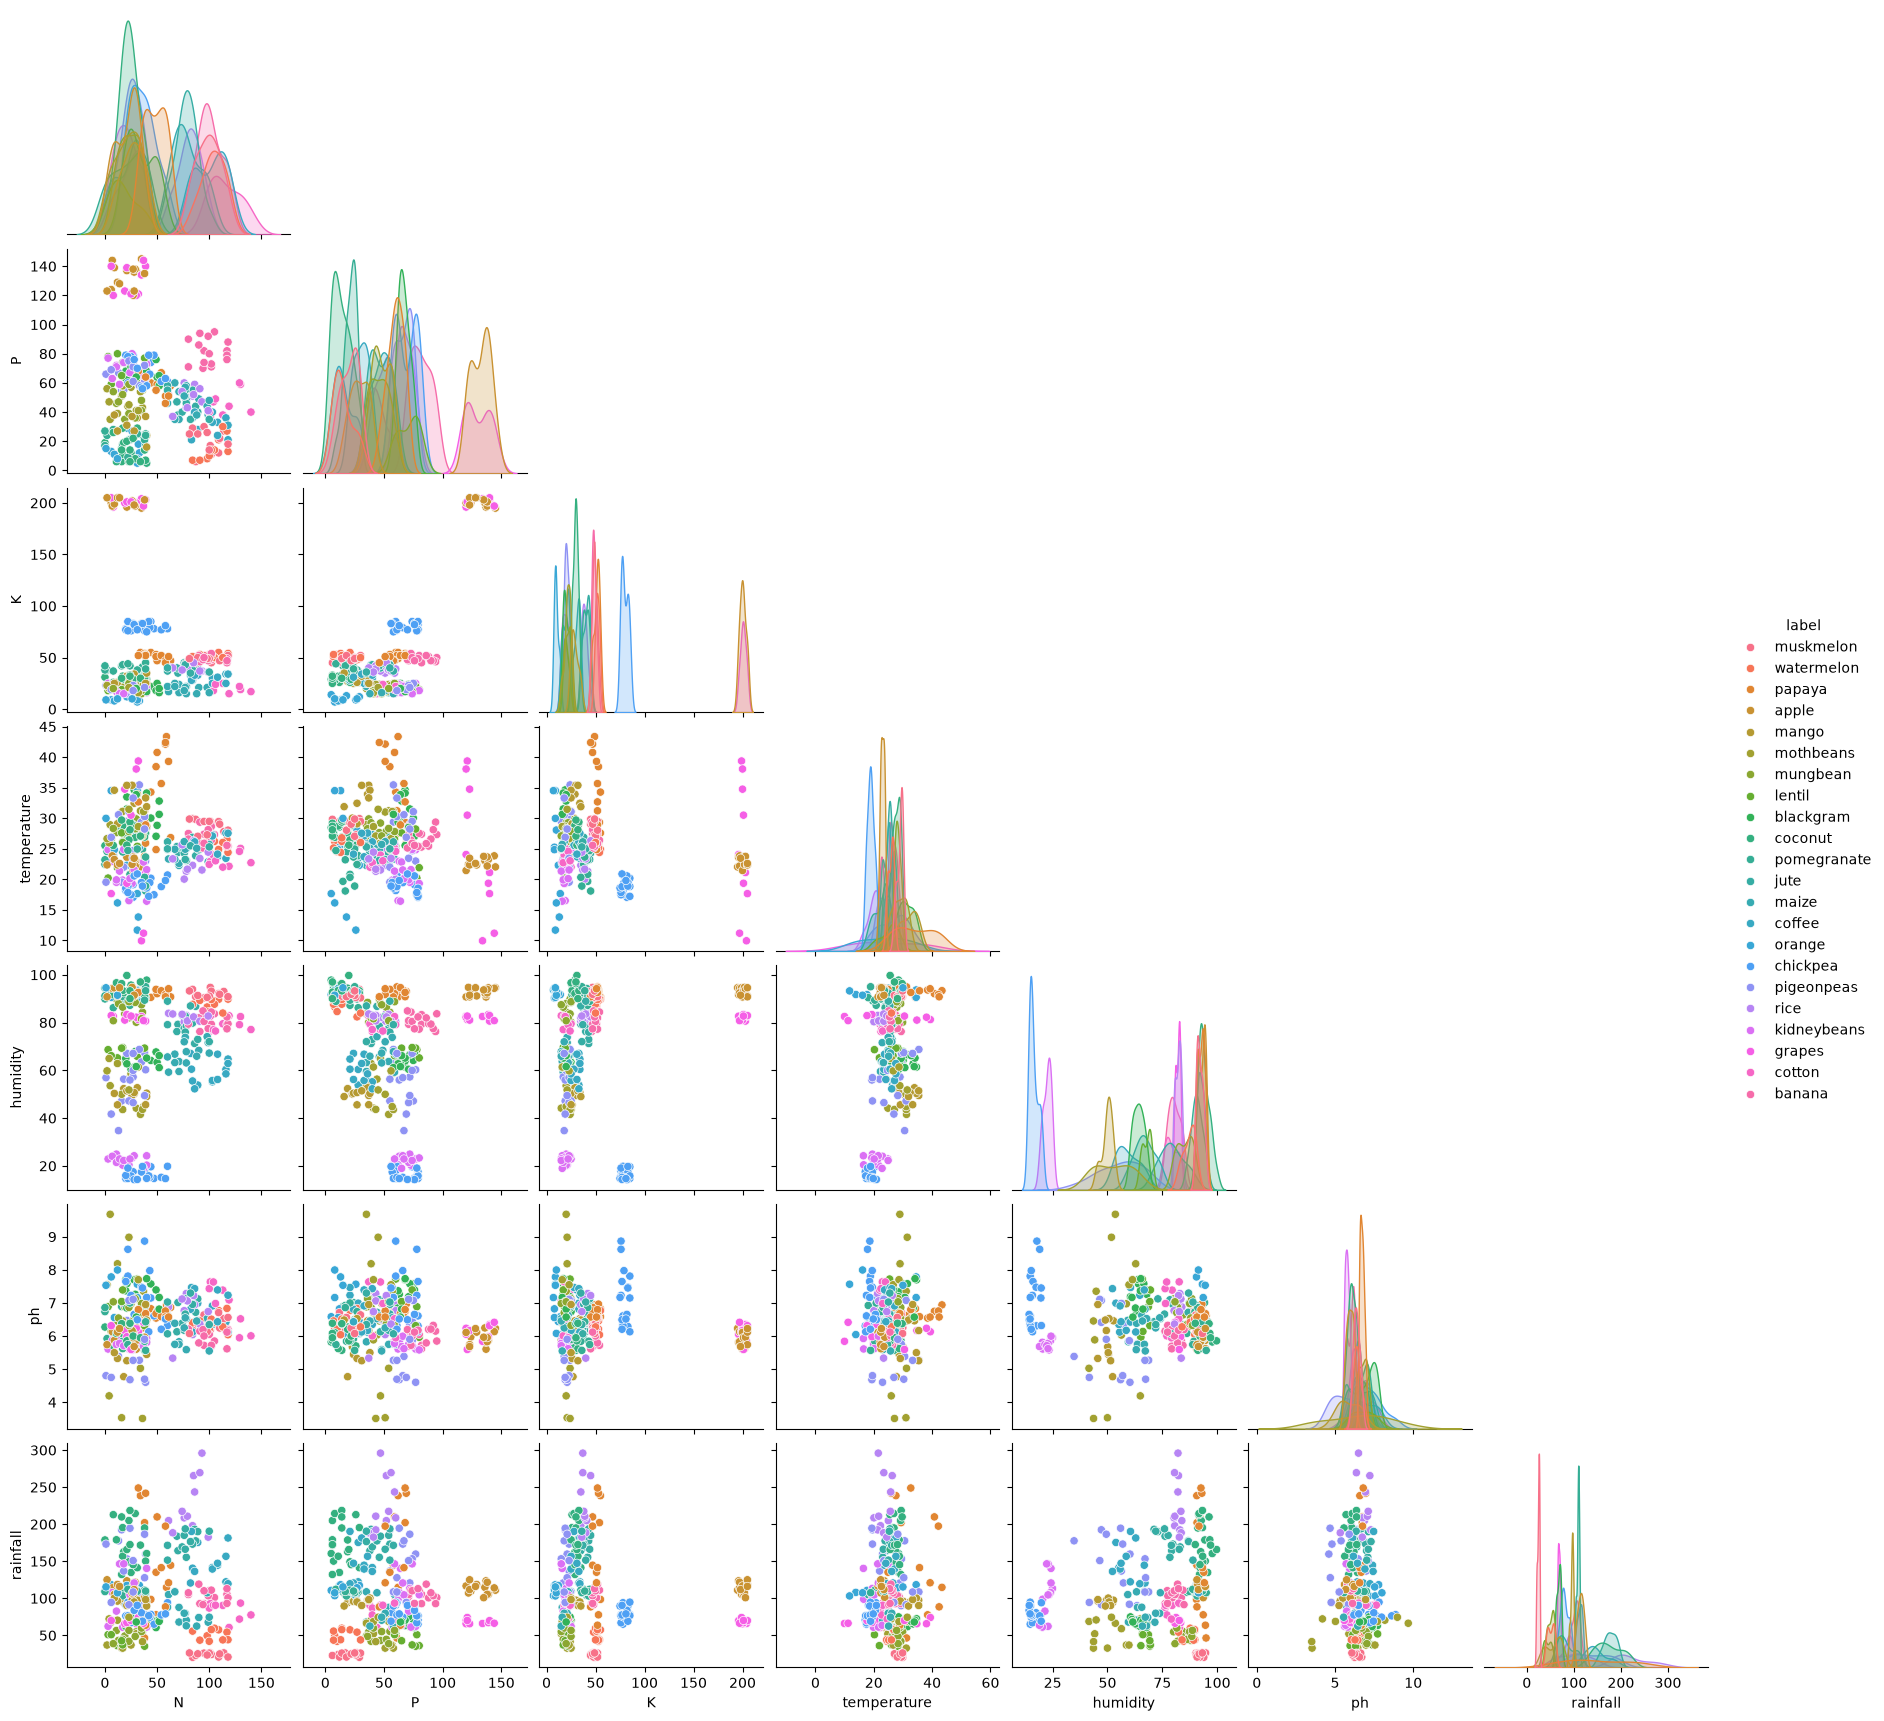

In [21]:
# Visualize pairwise relationships among features

sns.pairplot(
    df.sample(300, random_state=42),
    hue="label",
    corner=True
)

plt.savefig(
    "outputs/figures/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Pairwise relationships reveal natural grouping among several crop classes.
- Random Forest leverages these nonlinear relationships to improve prediction accuracy.

# 5. Data Preprocessing

Before training the Random Forest model, the dataset is prepared by separating the features and target variable, encoding the crop labels, and splitting the data into training and testing sets.

Unlike distance-based algorithms, Random Forest does **not** require feature scaling.

In [22]:
# Separate the features and target variable

X = df.drop("label", axis=1)
y = df["label"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (2200, 7)
Target Shape : (2200,)


In [23]:
# Encode crop labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Number of Crop Classes :", len(encoder.classes_))

Number of Crop Classes : 22


In [24]:
# Save encoded crop labels

pd.DataFrame({
    "Encoded Value": range(len(encoder.classes_)),
    "Crop": encoder.classes_
}).to_csv(
    "outputs/tables/encoded_crop_labels.csv",
    index=False
)

In [25]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (1760, 7)
Testing Features : (440, 7)
Training Labels : (1760,)
Testing Labels : (440,)


In [26]:
# Save sample training data

X_train.head().to_csv(
    "outputs/tables/training_features.csv",
    index=False
)

pd.DataFrame(
    y_train,
    columns=["Encoded Crop"]
).head().to_csv(
    "outputs/tables/training_labels.csv",
    index=False
)

### Insights

- The crop labels were converted into numerical values using Label Encoding.
- The dataset has been divided into training and testing sets using an 80:20 split.
- Stratified sampling preserves the distribution of all crop classes.
- Random Forest can directly learn from the original feature values without feature scaling.

# 6. Model Training

In this section, a Random Forest Classifier is trained using the prepared training dataset.

Unlike a single Decision Tree, Random Forest builds multiple decision trees on different subsets of the data and combines their predictions to improve accuracy and reduce overfitting.

In [27]:
# Train the Random Forest model

model = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=12,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [28]:
# Display the Out-of-Bag score

print(f"OOB Score : {model.oob_score_:.4f}")

OOB Score : 0.9955


In [29]:
# Save the Out-of-Bag score

pd.DataFrame({
    "Metric":["OOB Score"],
    "Value":[model.oob_score_]
}).to_csv(
    "outputs/tables/oob_score.csv",
    index=False
)

### Insights

- The Random Forest model has been successfully trained.
- Multiple Decision Trees are combined to improve prediction robustness.
- The Out-of-Bag (OOB) score provides an internal estimate of model performance without requiring additional validation data.

# 7. Prediction

The trained Random Forest model predicts the recommended crop for unseen agricultural observations and estimates the probability associated with each prediction.

In [30]:
# Predict crop labels

y_pred = model.predict(X_test)

y_pred[:10]

array([16,  1,  6, 11, 16,  3, 20,  2,  1, 16])

In [31]:
# Predict crop probabilities

y_prob = model.predict_proba(X_test)

y_prob[:5]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        9.66301370e-01, 0.00000000e+00, 0.00000000e+00, 3.36986301e-02,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 9.57037037e-01, 5.00000000e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 5.00000000e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.50000000e-02, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.79629630e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 9.89250000e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00

In [32]:
# Save sample predictions

predictions = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred)
})

predictions.head(20).to_csv(
    "outputs/tables/sample_predictions.csv",
    index=False
)

### Insights

- The model predicts the most suitable crop for each observation.
- Prediction probabilities indicate the confidence of the ensemble model.
- These predictions will be evaluated using multi-class classification metrics.